In [15]:
import numpy
import pandas as pd
import matplotlib as plt
import seaborn as sea
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor,RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/Users/manavkumar/Desktop/AIML Course/project/data/stud.csv')

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
x=df.drop(columns=['math_score'])

In [9]:
y=df['math_score']

In [11]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [12]:
num_features=x.select_dtypes(exclude='object').columns
cat_features=x.select_dtypes(include='object').columns

In [13]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()
preprocessor=ColumnTransformer(
    [
        ("StandardScalar",numeric_transformer,num_features),
        ("OneHotEncoder",oh_transformer,cat_features)
    ]
)

In [14]:
x=preprocessor.fit_transform(x)

In [16]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

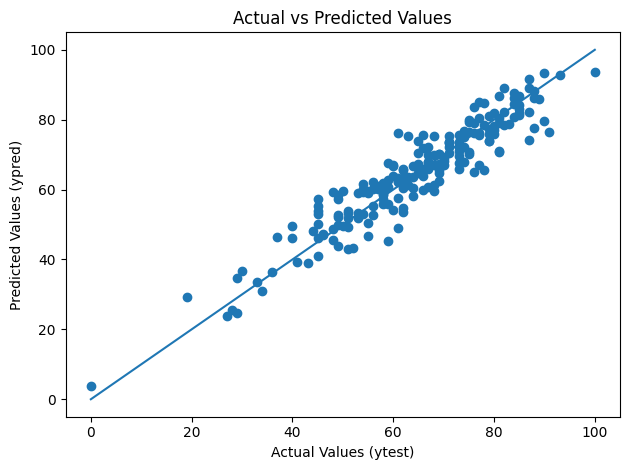

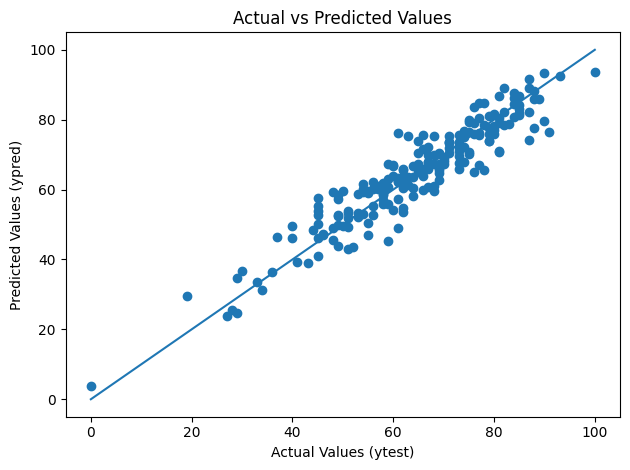

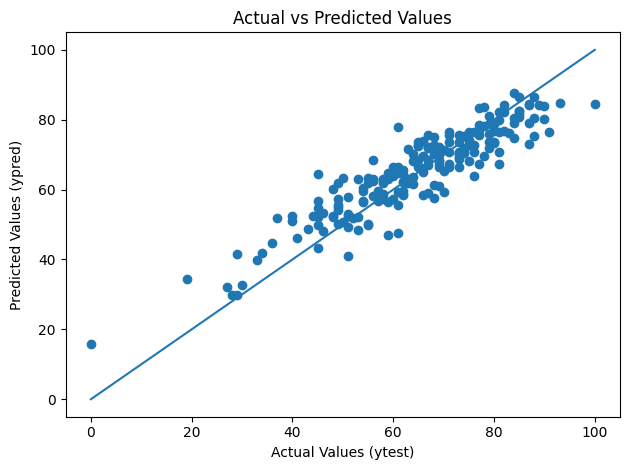

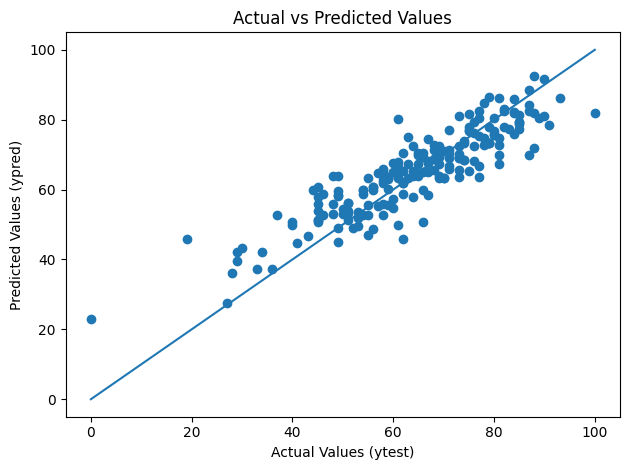

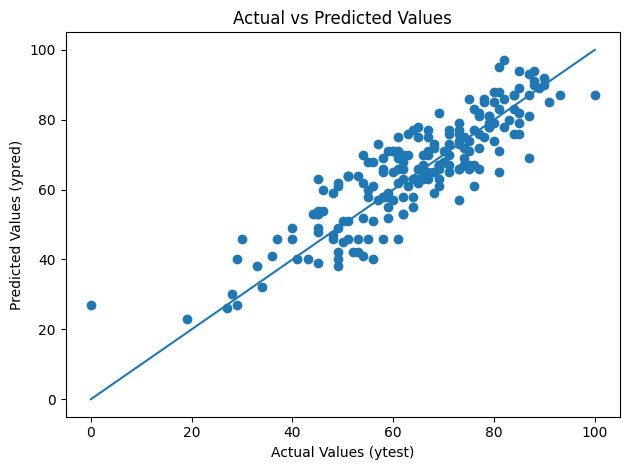

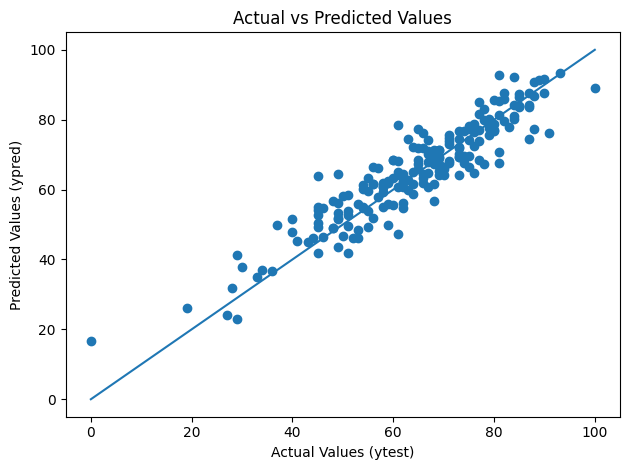

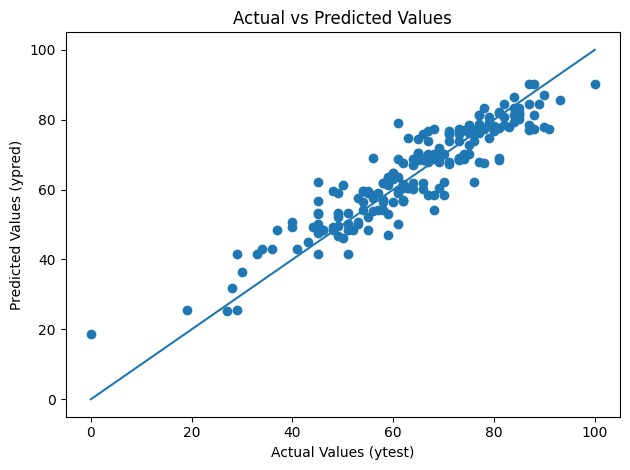

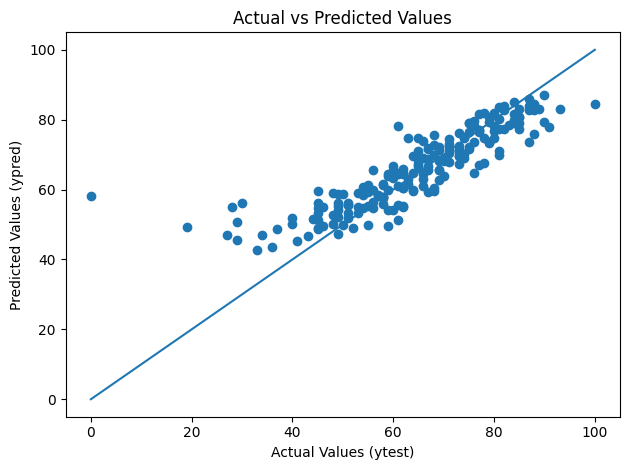

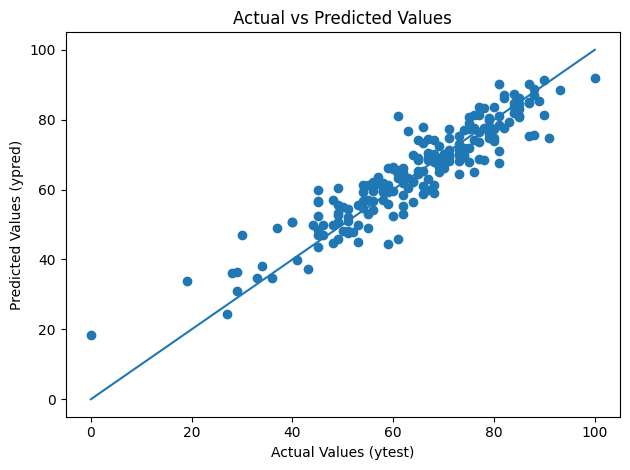

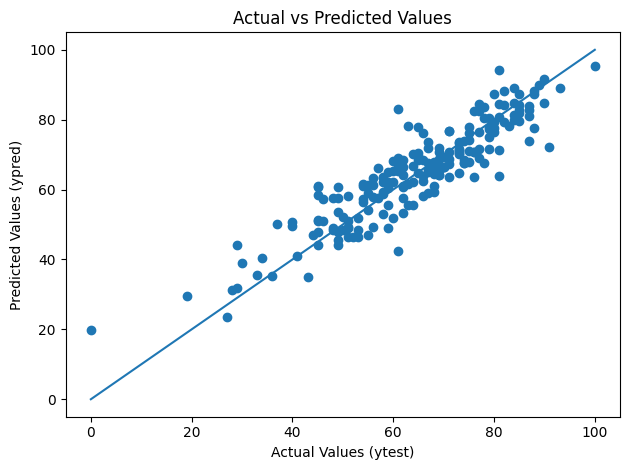

,Model,R2,MAE
1,Ridge,0.880593,4.211101
0,Linear Regression,0.880433,4.214763
5,Random Forest,0.850403,4.705967
6,AdaBoost,0.850225,4.724614
8,CatBoost,0.850185,4.601510
2,Lasso,0.825320,5.157879
9,XGBoost,0.821221,5.103630
3,KNN,0.783770,5.619000
4,Decision Tree,0.748252,6.230000
7,SVR,0.728600,5.401539


In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "SVR": SVR(),
    "CatBoost": CatBoostRegressor(
        verbose=0,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        verbosity=0
    )
}

results = []

for name, model in models.items():
    model.fit(xtrain, ytrain)
    ypred = model.predict(xtest)

    results.append({
        "Model": name,
        "R2": r2_score(ytest, ypred),
        "MAE": mean_absolute_error(ytest, ypred),
    })

    plt.figure()
    plt.scatter(ytest, ypred)
    plt.xlabel("Actual Values (ytest)")
    plt.ylabel("Predicted Values (ypred)")
    plt.title("Actual vs Predicted Values")

    # Perfect prediction reference line
    plt.plot(
        [ytest.min(), ytest.max()],
        [ytest.min(), ytest.max()]
    )

    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

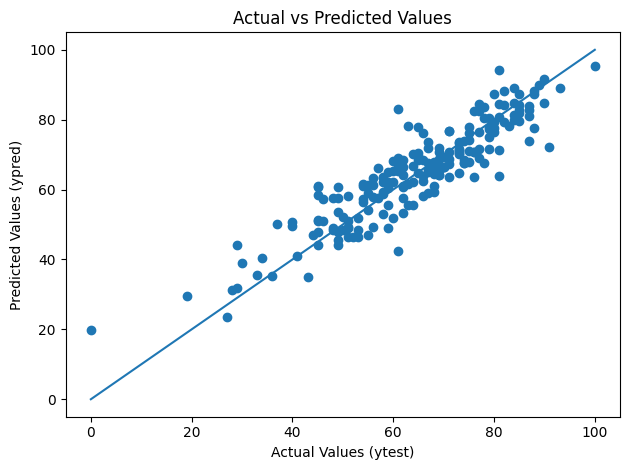